# Initial Analysis

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


**Types of Foreign Gifts**
- Monetary Gift - a direct financial contribution such as cash, wire transfer, etc.
- Contract - formal agreement for things like research, services, sponsorships, etc.
- Real Estate - a gift involving property or real estate such as land or a building donated to an institution

In [5]:
#Which country gives the most money, in total?
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)

#ANSWER: Qatar

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
CANADA           898160656
HONG KONG        887402529
JAPAN            655954776
SWITZERLAND      619899445
INDIA            539556490
Name: Foreign Gift Amount, dtype: int64

In [6]:
#Which country initiates the most gifts, by count?
df.groupby('Country of Giftor')['ID'].count().sort_values(ascending=False).head(10)

#ANSWER: England

Country of Giftor
ENGLAND         3655
CHINA           2461
CANADA          2344
JAPAN           1896
SWITZERLAND     1676
SAUDI ARABIA    1610
FRANCE          1437
GERMANY         1394
HONG KONG       1080
SOUTH KOREA      811
Name: ID, dtype: int64

In [7]:
#Which country gives the largest gifts, on average?
df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending=False).head(10)

#ANSWER: Bermuda

Country of Giftor
BERMUDA     7.688837e+06
ECUADOR     3.985140e+06
QATAR       3.905109e+06
ANTIGUA     3.435545e+06
JERSEY      3.064589e+06
MOROCCO     2.740214e+06
RUSSIA      2.025462e+06
GUERNSEY    1.750000e+06
IRAQ        1.665520e+06
CYPRUS      1.562512e+06
Name: Foreign Gift Amount, dtype: float64

In [8]:
#Which institution receives the most money, in total?
df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)

#ANSWER: Carnegie Mellon University

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
Texas A&M University                      521455050
Johns Hopkins University                  502409595
Northwestern University                   402316221
Georgetown University                     379950511
University of Chicago (The)               364544338
Name: Foreign Gift Amount, dtype: int64

In [9]:
#Which institution receive the greatest number of gifts, by count?
df.groupby('Institution Name')['ID'].count().sort_values(ascending=False).head(10)

#ANSWER: University of California, Los Angeles

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
University of Michigan - Ann Arbor              715
Stanford University                             668
Cornell University                              653
University of Pennsylvania                      625
Massachusetts Institute of Technology           582
Name: ID, dtype: int64

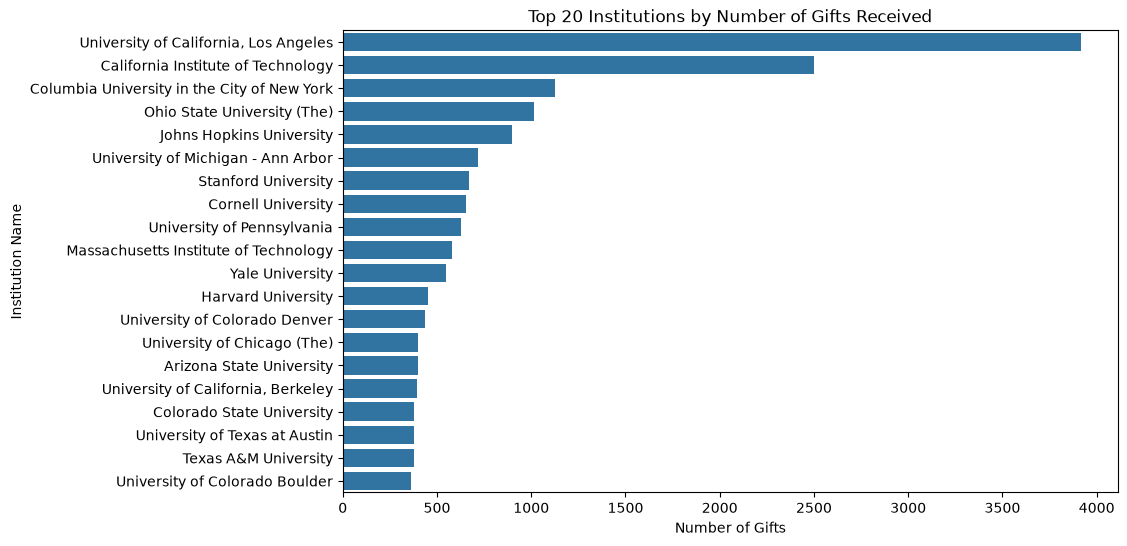

In [10]:
#Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly.

top_institutions_count = df.groupby('Institution Name')['ID'].count().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_institutions_count.values, y=top_institutions_count.index)
plt.title('Top 20 Institutions by Number of Gifts Received')
plt.xlabel('Number of Gifts')
plt.ylabel('Institution Name')
plt.show()


In [14]:
#What is the average amount each university receives? Median amount? If they are different, why?
mean_amt = df['Foreign Gift Amount'].mean()
median_amt = df['Foreign Gift Amount'].median()
print(mean_amt)
print(median_amt)

#The average and median amounts are different because the average is affected by outliers, while the median is not. If a university receives a very large gift, it can skew the average upwards, while the median will remain more representative of the typical gift amount.

588232.7172672832
94615.0


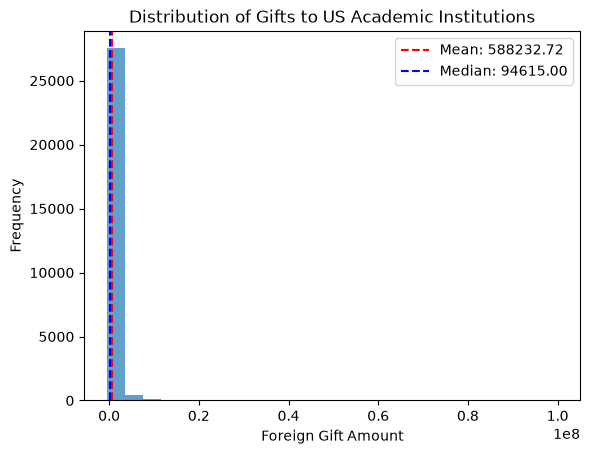

In [19]:
#Histogram of the amounts received by each university, and then label the median and the mean as vertical lines.

plt.hist(df['Foreign Gift Amount'], bins=25, alpha=0.7)
plt.axvline(mean_amt, color='red', linestyle='--', label=f'Mean: {mean_amt:.2f}')
plt.axvline(median_amt, color='blue', linestyle='--', label=f'Median: {median_amt:.2f}')
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Gifts to US Academic Institutions')
plt.legend()
plt.show()

In [12]:
#What is the largest flow of a single country to a single institution?
pd.crosstab(df['Institution Name'], 
            df['Country of Giftor'], 
            values=df['Foreign Gift Amount'], 
            aggfunc='sum'
            ).stack().sort_values(ascending=False).head(10)

#ANSWER: Qatar --> Cornell University

Institution Name                Country of Giftor   
Cornell University              QATAR                   1.018473e+09
Carnegie Mellon University      BERMUDA                 7.500000e+08
Texas A&M University            QATAR                   5.040994e+08
Carnegie Mellon University      QATAR                   4.254107e+08
Georgetown University           QATAR                   3.271283e+08
Northwestern University         QATAR                   3.111486e+08
Brigham Young University        CANADA                  2.599278e+08
University of Colorado Boulder  UNITED ARAB EMIRATES    2.197348e+08
Harvard University              ENGLAND                 1.883283e+08
Yale University                 HONG KONG               1.611312e+08
dtype: float64

In [13]:
#Which are the top giftors to US academic institutions?
top_country = df.groupby(["Institution Name", "Giftor Name"])["Foreign Gift Amount"].sum().reset_index()
top_country = top_country.loc[top_country.groupby("Institution Name")["Foreign Gift Amount"].idxmax()]
top_country.sort_values("Foreign Gift Amount", ascending=False).head(10)

,Institution Name,Giftor Name,Foreign Gift Amount
1707,Cornell University,Qatar Foundation/Qatar National Res,796197000
3461,Texas A&M University,Qatar Foundation,465638397
920,Carnegie Mellon University,Qatar Foundation for Education,373914113
2081,Georgetown University,Qatar Foundation,314161323
2845,Northwestern University,Qatar Foundation,305556268
2670,New York University,Anonymous,190861196
6832,University of Colorado Boulder,Emirates Institute for Advanced Sc,170641244
8602,University of Phoenix,HCL,152000000
2727,Northeastern University,QIC,148355497
254,Brigham Young University,Church of Jesus Christ of LDS,115831693
